<a href="https://colab.research.google.com/github/nhimoc31231020361-cmd/nhimoc.github.io/blob/nm-pages/LAB03_thuchanhgk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import thư viện và load dữ liệu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
penguins = sns.load_dataset('penguins')  # Có sẵn trong seaborn
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


2. Xây dựng mô hình K-Means

In [ ]:
# Drop rows with missing values
penguins_cleaned = penguins.dropna()

# Select the numerical features for clustering
X = penguins_cleaned[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

display(X.head())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(X_scaled[:5])

array([[-0.89604189,  0.7807321 , -1.42675157, -0.56847478],
       [-0.82278787,  0.11958397, -1.06947358, -0.50628618],
       [-0.67627982,  0.42472926, -0.42637319, -1.1903608 ],
       [-1.33556603,  1.0858774 , -0.56928439, -0.94160639],
       [-0.85941488,  1.74702554, -0.78365118, -0.69285199]])

In [ ]:
km_inertias = []
km_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertia = km.inertia_
    score = silhouette_score(X_scaled, km.labels_)
    km_inertias.append(inertia)
    km_scores.append(score)
    print(f"k = {k} | Inertia = {inertia:.2f} | Silhouette Score = {score:.4f}")


k = 2 | Inertia = 552.67 | Silhouette Score = 0.5308
k = 3 | Inertia = 370.77 | Silhouette Score = 0.4462
k = 4 | Inertia = 305.43 | Silhouette Score = 0.4191
k = 5 | Inertia = 228.70 | Silhouette Score = 0.3740
k = 6 | Inertia = 200.60 | Silhouette Score = 0.3657
k = 7 | Inertia = 187.33 | Silhouette Score = 0.3541
k = 8 | Inertia = 167.14 | Silhouette Score = 0.2992
k = 9 | Inertia = 160.55 | Silhouette Score = 0.2645
k = 10 | Inertia = 155.83 | Silhouette Score = 0.2399


3. Tìm số cụm tối ưu cho mô hình K-Mean bằng phương pháp Elbow

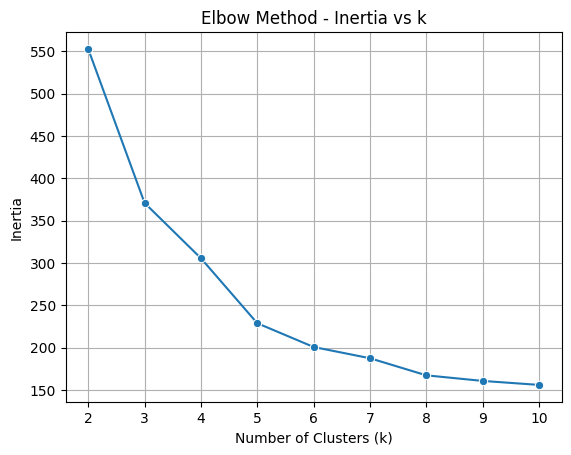

In [ ]:
sns.lineplot(x=range(2, 11), y=km_inertias, marker='o')
plt.title('Elbow Method - Inertia vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


4. Tìm số cụm tối ưu bằng phương pháp Silhoutte

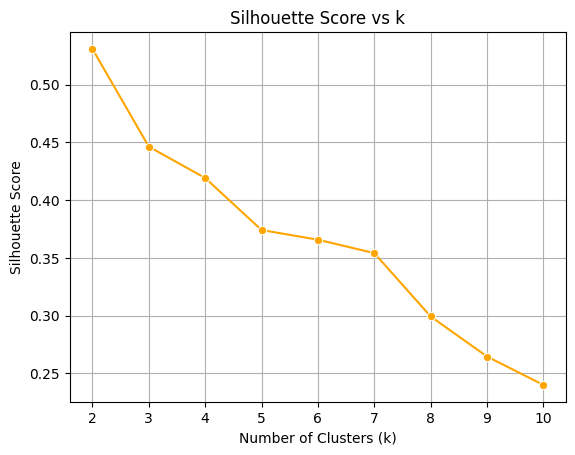

In [ ]:
sns.lineplot(x=range(2, 11), y=km_scores, marker='o', color='orange')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


5. Gán nhãn cho các mẫu dữ liệu dựa vào mô hình K-Means với số cụm là 3

In [ ]:
# Huấn luyện mô hình
km = KMeans(n_clusters=3, random_state=42)
penguins_cleaned['cluster'] = km.fit_predict(X_scaled)

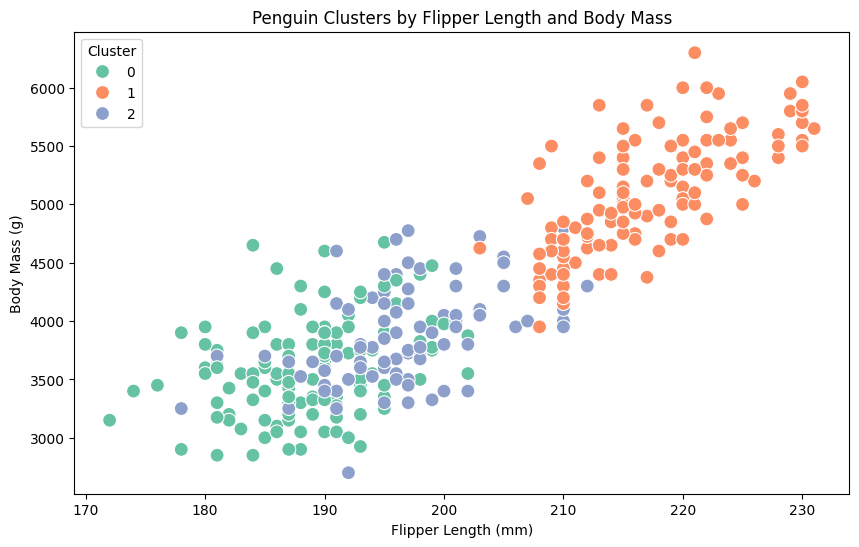

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins_cleaned, x='flipper_length_mm', y='body_mass_g', hue='cluster', palette='Set2', s=100)
plt.title('Penguin Clusters by Flipper Length and Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Cluster')
plt.show()